In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans




In [2]:
df = pd.read_csv(r"C:\Users\javier.sdiaz\Proyecto ML_2025\data\processed\datos_procesados.csv", sep=",")
df

,Temp_amb,Dir_viento,Vel_viento,Energia,Potencia,Oil_Temp,cosPhi,Frecuencia,Temp_int,Q,Año,Estacion,Rad_prom,HeatsinkTemp_prom,Idc_total,V_total,Minuto_sin,Hora_sin,Dia_sin,Mes_sin
0,11.346512,222.558422,2.611367,26.931747,0.0,26.079072,0.0,49.960499,20.329768,0.0,2022,1,0.0,17.075259,0.0,1146.307697,0.000000e+00,0.000000,0.781831,5.000000e-01
1,11.300000,223.087589,2.582713,0.000000,0.0,25.479083,0.0,49.959999,20.179770,0.0,2022,1,0.0,16.883596,0.0,1147.522942,1.000000e+00,0.000000,0.781831,5.000000e-01
2,11.306667,224.893609,2.640629,0.000000,0.0,24.879095,0.0,49.959999,20.029773,0.0,2022,1,0.0,16.691933,0.0,1150.385870,5.665539e-16,0.000000,0.781831,5.000000e-01
3,11.293333,223.534547,2.808005,0.000000,0.0,24.279182,0.0,49.959999,19.879776,0.0,2022,1,0.0,16.506316,0.0,1153.091744,-1.000000e+00,0.000000,0.781831,5.000000e-01
4,11.259853,230.927235,3.147298,0.000000,0.0,23.745968,0.0,49.960503,19.741495,0.0,2022,1,0.0,16.404334,0.0,1150.639247,0.000000e+00,0.258819,0.781831,5.000000e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105211,4.145149,223.663976,5.285611,740.750000,0.0,8.529718,0.0,50.000000,10.085310,0.0,2024,1,0.0,7.151938,0.0,1145.415732,-1.000000e+00,-0.500000,0.433884,-2.449294e-16
105212,4.245148,219.700928,5.490529,740.750000,0.0,8.329723,0.0,50.000000,10.117952,0.0,2024,1,0.0,7.165451,0.0,1145.233798,0.000000e+00,-0.258819,0.433884,-2.449294e-16
105213,4.376957,222.824833,5.048825,740.750000,0.0,8.329723,0.0,50.000000,10.117952,0.0,2024,1,0.0,7.165451,0.0,1145.233798,1.000000e+00,-0.258819,0.433884,-2.449294e-16
105214,4.493333,220.484426,4.876356,740.750000,0.0,8.329723,0.0,50.000000,10.117952,0.0,2024,1,0.0,7.165451,0.0,1145.233798,5.665539e-16,-0.258819,0.433884,-2.449294e-16


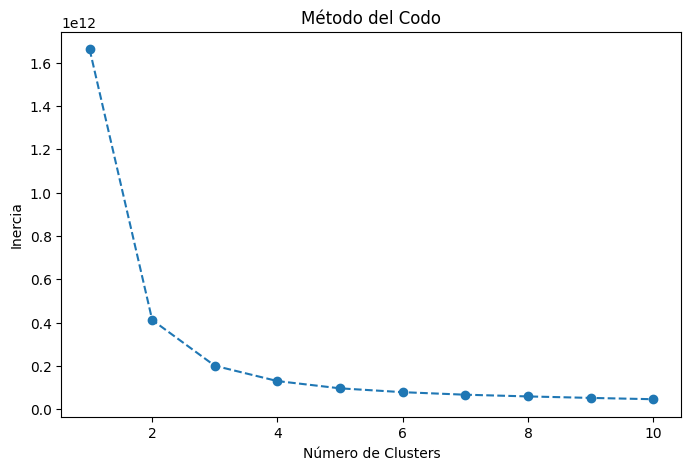

In [3]:
# 2. Determinar número óptimo de clusters con método del codo
inertia = []
K_range = range(1, 11)  # Probar de 1 a 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

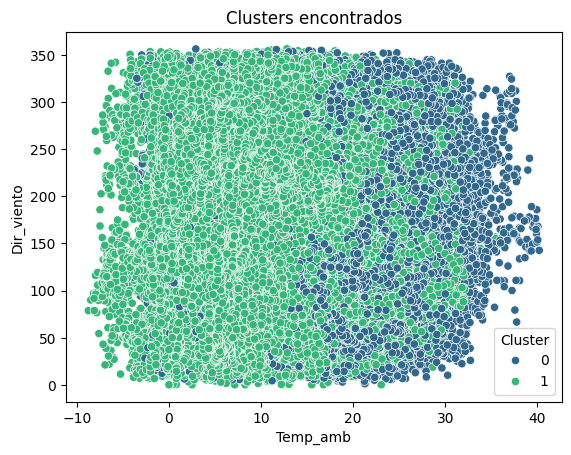

In [4]:
# 3. Aplicar K-Means con el número óptimo de clusters (3)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df)

# 4. Visualizar los clusters (si hay dos dimensiones)
sns.scatterplot(x=df.iloc[:, 0], y=df.iloc[:, 1], hue=df['Cluster'], palette='viridis')
plt.title("Clusters encontrados")
plt.show()

In [5]:
X = df.drop(columns=['Energia'])  
y = df['Energia']


In [6]:
# Almacenar métricas de evaluación
resultados = {}

for cluster in df['Cluster'].unique():
    print(f"\nEntrenando modelo para Cluster {cluster}...")
    
    # Filtrar datos del cluster
    X_cluster = X[df['Cluster'] == cluster]
    y_cluster = y[df['Cluster'] == cluster]
    
    # Dividir en entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(X_cluster, y_cluster, test_size=0.2, random_state=42)

    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Entrenar modelo (ejemplo: Regresión Lineal)
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    
    # Predicciones
    y_pred = model.predict(X_test_scaled)
    
    # Evaluación
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    resultados[cluster] = {'MAE': mae, 'MSE': mse, 'R2': r2}

    print(f"Cluster {cluster} - MAE: {mae:.4f}, MSE: {mse:.4f}, R²: {r2:.4f}")

# Mostrar métricas finales
print("\nResultados finales por cluster:")
for cluster, metrics in resultados.items():
    print(f"Cluster {cluster} -> MAE: {metrics['MAE']:.4f}, MSE: {metrics['MSE']:.4f}, R²: {metrics['R2']:.4f}")



Entrenando modelo para Cluster 1...
Cluster 1 - MAE: 579.3778, MSE: 657138.9520, R²: 0.6534

Entrenando modelo para Cluster 0...
Cluster 0 - MAE: 1864.1091, MSE: 5320647.5699, R²: 0.3963

Resultados finales por cluster:
Cluster 1 -> MAE: 579.3778, MSE: 657138.9520, R²: 0.6534
Cluster 0 -> MAE: 1864.1091, MSE: 5320647.5699, R²: 0.3963
